In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import datetime
import pytz

NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
LDN_tz = pytz.timezone("Europe/London") 
UTC_tz = pytz.timezone("UTC") 

import sys
sys.path.append("../")

In [2]:
from MDP.IRSwaptions.IRSwaptionMDP import IRSwaptionMDP
from Query.Base.query_resolution import resolve_query
from Query.IRSwaptions import IRSwaptionQuery, IRSwaptionStructure, IRSwaptionValue


In [3]:
# mdp = IRSwaptionMDP(
#     source="GSQUANT-QL",
#     curve_source="ERIS_EOD_LIVE-QL_BASIC",
# )

# mdp = IRSwaptionMDP(
#     source="MONKEYCUBE-QL",
#     curve_source="ERIS_EOD_LIVE-QL_BASIC",
#     data_dir=r'C:\Users\chris\clee\ARBS\MDP\IRSwaptions\MONKEYCUBE\YCMONKEY_USD_VOL_CUBE_GAMMA_MIX'
# )

mdp = IRSwaptionMDP(
    source="GSQUANT_MC_ENHANCED-QL",
    curve_source="ERIS_EOD_LIVE-QL_BASIC",
    data_dir=r'C:\Users\chris\clee\ARBS\MDP\IRSwaptions\MONKEYCUBE\YCMONKEY_USD_VOL_CUBE_GAMMA_MIX'
)

In [6]:
as_of = datetime.date(2026, 3, 12)
ctx = mdp.get_pricer(
    {
        "curve_name": "USD-SOFR-1D",
        "timestamp": as_of,
        # "ignore_cache": True,
    }
)
ctx

IRSwaptionMarketContext(curve_name='USD-SOFR-1D', as_of_date=datetime.date(2026, 3, 12), curve=QLIRSwapCurve(_ql_curve_id='USD-SOFR-1D', _ql_curve_handle=<QuantLib.QuantLib.YieldTermStructureHandle; proxy of <Swig Object of type 'Handle< YieldTermStructure > *' at 0x000001974FD97F30> >, _ql_curve_index=<QuantLib.QuantLib.Sofr; proxy of <Swig Object of type 'ext::shared_ptr< Sofr > *' at 0x000001974FD97D70> >, _meta_data={'timestamp': datetime.date(2026, 3, 12)}), curve_handle=<QuantLib.QuantLib.YieldTermStructureHandle; proxy of <Swig Object of type 'Handle< YieldTermStructure > *' at 0x000001974FD97F30> >, swap_index=<QuantLib.QuantLib.Sofr; proxy of <Swig Object of type 'ext::shared_ptr< Sofr > *' at 0x000001974FD97D70> >, vol_handle=<QuantLib.QuantLib.SwaptionVolatilityStructureHandle; proxy of <Swig Object of type 'Handle< SwaptionVolatilityStructure > *' at 0x000001974C77D870> >, pricing_engine=<QuantLib.QuantLib.BachelierSwaptionEngine; proxy of <Swig Object of type 'ext::shared_

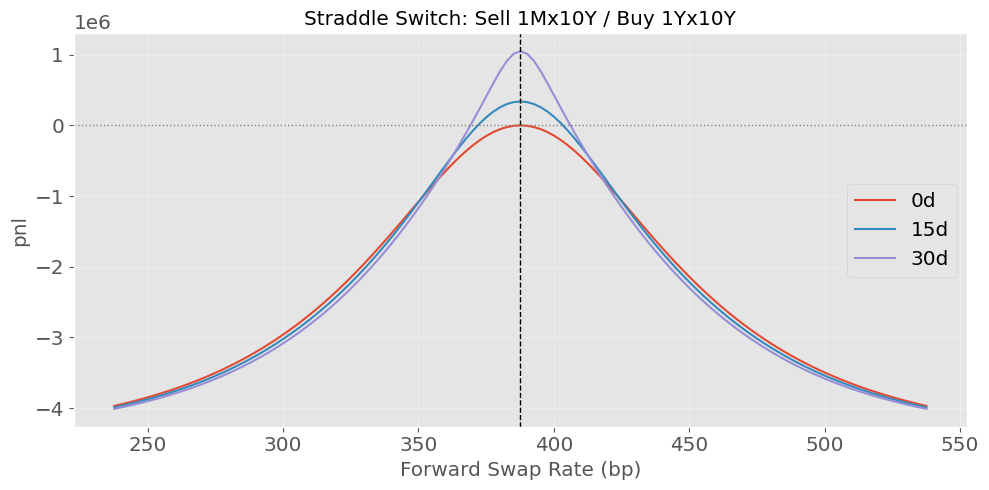

In [24]:
# from Simulation import ScenarioGrid, TimeDecay, UnderlyingShift, simulate_package
# from Query.IRSwaptions.pricer import leg_forward_rate

# q = IRSwaptionQuery(
# 	shorthand="1y10y",
# 	structure=IRSwaptionStructure.STRADDLE,
# 	structure_kwargs={"vega_01": 10_000, "side": "buy" },
# 	# side="buy",
# )

# pkg, _ = q.resolve_package(pricer_or_curve=ctx)
# days_to_expiry = 365
# base_fwd = leg_forward_rate(ctx, pkg[0])

# shift_grid = np.linspace(-0.0150, 0.0150, 121).tolist()

# grid = ScenarioGrid(
#     axes=[
#         (UnderlyingShift, "shift", shift_grid),
#         (TimeDecay, "days", [0, days_to_expiry // 2, days_to_expiry]),
#     ]
# )

# metric = "pnl"

# result = simulate_package(
#     query=q,
#     pricer=ctx,
#     grid=grid,
#     metrics=[metric],
#     include_pnl=True,
# )

# df = result.to_dataframe(metric)

# expiry_curve = df[days_to_expiry]

# x_rate_bps = (base_fwd + expiry_curve.index.to_numpy()) * 10_000
# atm_bps = base_fwd * 10_000

# fig, ax = plt.subplots(figsize=(10, 5))
# ax.plot(x_rate_bps, expiry_curve.to_numpy(), lw=2, label="Expiry")
# ax.axvline(atm_bps, color="black", ls="--", lw=1, label="ATM forward")
# ax.axhline(0.0, color="grey", ls=":", lw=1)

# ax.set_title(f"{q.col_name()} Payoff at Expiry")
# ax.set_xlabel("Forward Swap Rate (bp)")
# ax.set_ylabel(metric)
# ax.grid(True, alpha=0.3)
# ax.legend()
# plt.tight_layout()
# plt.show()

# fig, ax = plt.subplots(figsize=(10, 5))
# for days in df.columns:
#     x_rate_bps = (base_fwd + df.index.to_numpy()) * 10_000
#     ax.plot(x_rate_bps, df[days].to_numpy(), label=f"{days}d")

# ax.axvline(base_fwd * 10_000, color="black", ls="--", lw=1)
# ax.set_title(f"{q.col_name()} Value vs Underlying")
# ax.set_xlabel("Forward Swap Rate (bp)")
# ax.set_ylabel(metric)
# ax.grid(True, alpha=0.3)
# ax.legend()
# plt.tight_layout()
# plt.show()

from Simulation import ScenarioGrid, TimeDecay, UnderlyingShift, simulate_package
from Query.IRSwaptions.pricer import leg_forward_rate

# --- Define the two legs ---
q_short = IRSwaptionQuery(
    shorthand="1m10y",
    structure=IRSwaptionStructure.STRADDLE,
    structure_kwargs={"gamma_01": 10_000, "side": "sell"},
)
q_long = IRSwaptionQuery(
    shorthand="1y10y",
    structure=IRSwaptionStructure.STRADDLE,
    structure_kwargs={"gamma_01": 10_000, "side": "buy"},
)

# Use the longer-dated leg's forward as the reference
pkg_long, _ = q_long.resolve_package(pricer_or_curve=ctx)
base_fwd = leg_forward_rate(ctx, pkg_long[0])

# Same grid for both — key requirement
shift_grid = np.linspace(-0.0150, 0.0150, 121).tolist()
days = [0, 15, 30]  # 1M10Y expires ~30d, so focus there

grid = ScenarioGrid(
    axes=[
        (UnderlyingShift, "shift", shift_grid),
        (TimeDecay, "days", days),
    ]
)

# --- Simulate each leg independently ---
metric = "pnl"
r_short = simulate_package(query=q_short, pricer=ctx, grid=grid, metrics=[metric], include_pnl=True)
r_long  = simulate_package(query=q_long,  pricer=ctx, grid=grid, metrics=[metric], include_pnl=True)

df_short = r_short.to_dataframe(metric)
df_long  = r_long.to_dataframe(metric)

# --- Switch P&L = long leg + short leg ---
df_switch = df_long + df_short  # short leg already has negative sign from side="sell"

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))
x_rate_bps = (base_fwd + df_switch.index.to_numpy()) * 10_000
for d in df_switch.columns:
    ax.plot(x_rate_bps, df_switch[d].to_numpy(), label=f"{d}d")
ax.axvline(base_fwd * 10_000, color="black", ls="--", lw=1)
ax.axhline(0.0, color="grey", ls=":", lw=1)
ax.set_title("Straddle Switch: Sell 1Mx10Y / Buy 1Yx10Y")
ax.set_xlabel("Forward Swap Rate (bp)")
ax.set_ylabel(metric)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


In [29]:
q = IRSwaptionQuery(shorthand="1y10y", structure=IRSwaptionStructure.STRADDLE, structure_kwargs={"vega_01": 10_000})
q_eff = resolve_query(q, timestamp=as_of, pricer_or_curve=ctx)
package, weights = q_eff.resolve_package(pricer_or_curve=ctx)
vmap = q_eff.build_value_map(pricer_or_curve=ctx, package=package, risk_weights=weights)
float(vmap.apply(IRSwaptionValue.NVOL)), float(vmap.apply(IRSwaptionValue.FWD_PREM)), float(vmap.apply(IRSwaptionValue.FWD_NPV)), float(vmap.apply(IRSwaptionValue.GAMMA_01))

(83.1506534275052, 553.7238543021678, 86239614.65269834, 118.5610787999526)

In [14]:
q = IRSwaptionQuery(
	shorthand="1y1y",
    # strike="ATMF",
    strike="ATMF+200",
    structure_kwargs={"notional": 100_000_000}
)

q_eff = resolve_query(q, timestamp=as_of, pricer_or_curve=ctx)
package, weights = q_eff.resolve_package(pricer_or_curve=ctx)
vmap = q_eff.build_value_map(pricer_or_curve=ctx, package=package, risk_weights=weights)
float(vmap.apply(IRSwaptionValue.NVOL)), float(vmap.apply(IRSwaptionValue.FWD_PREM)), float(vmap.apply(IRSwaptionValue.VEGA_01))

(260.70998625020206, 33.24116440883732, 2856.9753722339487)

In [15]:
q = IRSwaptionQuery(
	shorthand="1y1y",
    strike="ATMF-100",
)

q_eff = resolve_query(q, timestamp=as_of, pricer_or_curve=ctx)
package, weights = q_eff.resolve_package(pricer_or_curve=ctx)
vmap = q_eff.build_value_map(pricer_or_curve=ctx, package=package, risk_weights=weights)
float(vmap.apply(IRSwaptionValue.NVOL)), float(vmap.apply(IRSwaptionValue.FWD_PREM))

(103.03660408100285, 9.150862996426993)

In [51]:
from MDP.STIRCapFloors.STIRCapFloorMDP import STIRCapFloorMDP
from Query.STIRCapFloors.STIRCapFloorQuery import STIRCapFloorQuery
from Query.STIRCapFloors.STIRCapFloorStructure import STIRCapFloorStructure
from Query.STIRCapFloors.STIRCapFloorValue import STIRCapFloorValue

capfloor_mdp = STIRCapFloorMDP(
    curve_source="ERIS_EOD_LIVE-QL_BASIC",
    option_source="BARCHART_STIRFO-QL",
)

q = STIRCapFloorQuery(
    structure=STIRCapFloorStructure.CAP,
    shorthand="1Yx2Y",
    weight_method="duration",
    strike_convention="atm_per_caplet",
)

ctx = capfloor_mdp.get_pricer(q.build_mdp_request(datetime.date(2026, 3, 10)))
ctx

STIRCapFloorMarketContext(structure='CAP', curve_name='USD-SOFR-1D', as_of_date=datetime.date(2026, 3, 10), swap_start=datetime.date(2027, 3, 17), swap_end=datetime.date(2029, 3, 21), weight_method='duration', strike_convention='atm_per_caplet', contracts=1.0, curve=QLIRSwapCurve(_ql_curve_id='USD-SOFR-1D', _ql_curve_handle=<QuantLib.QuantLib.YieldTermStructureHandle; proxy of <Swig Object of type 'Handle< YieldTermStructure > *' at 0x0000018DBB0080F0> >, _ql_curve_index=<QuantLib.QuantLib.Sofr; proxy of <Swig Object of type 'ext::shared_ptr< Sofr > *' at 0x0000018DBB008130> >, _meta_data={'timestamp': datetime.date(2026, 3, 10)}), legs=(STIRCapFloorLegMarket(option_symbol='SFRH27|9675P', requested_symbol='SFRH27|ATMP', right='P', underlying_contract='SFRH27', reference_quarter_start=datetime.date(2027, 3, 17), reference_quarter_end=datetime.date(2027, 6, 16), strike_price=96.75, strike_rate=3.25, requested_strike_price=96.75, requested_strike_rate=3.25, economic_weight=0.1273674442916

In [52]:
ctx.id()
ctx.meta()["strip_contracts"]

# for leg in ctx.legs:
#     print(
#         leg.underlying_contract,
#         leg.option_symbol,
#         leg.requested_symbol,
#         leg.quote_source,
#         leg.economic_weight,
#     )

['SFRH27',
 'SFRM27',
 'SFRU27',
 'SFRZ27',
 'SFRH28',
 'SFRM28',
 'SFRU28',
 'SFRZ28']